# IMEN266 · Ch.5 · Class Problems 6 — Exponential distribution and Poisson process

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your answer
matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch05/notebooks/CP6_exponential_poisson.ipynb`

**The two facts of this notebook** *(slides pp. 1–3, 9–12/63; Companion Proofs 1–3)*

- $X\sim\exp(\lambda)$: $P(X>t)=e^{-\lambda t}$, $E[X]=1/\lambda$, and the
  **memoryless property** $P(X>t+s\mid X>s)=P(X>t)$. The **minimum** of independent
  $\exp(\lambda_i)$ clocks is $\exp(\sum_i\lambda_i)$, and clock $i$ rings first with
  probability $\lambda_i/\sum_j\lambda_j$.
- A **Poisson process** $PP(\lambda)$ counts events with iid $\exp(\lambda)$ gaps:
  $N(t)\sim$ Poisson$(\lambda t)$. **Thinning** a $PP(\lambda)$ with probability $p$
  gives $PP(\lambda p)$; **merging** independent $PP(\lambda_i)$ gives $PP(\sum\lambda_i)$.

In code: `stats.expon(scale=1/lam)`, `stats.poisson(lam*t)`, and from the course
package `poisson_process(rate, T, rng)`, `thin(times, p, rng)` (returns the kept and the dropped points), `merge(*times)`.

In [1]:
# --- IMEN266 setup (Ch.5): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import expm

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.ctmc import CTMC
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.ctmc import CTMC
from imen266.ctmc import (birth_death, bd_stationary, machine_repair, erlang_loss,
                          expm_series, expm_limit, poisson_process, thin, merge)
from imen266.dtmc import DTMC
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def build_ctmc(Q, states=None):
    """CTMC(Q) if Q is complete and valid; otherwise None (keeps 'Run all' alive)."""
    Q = np.asarray(Q, dtype=float)
    if np.isnan(Q).any():
        print("[TODO] Q still contains NaN entries - finish the TODO above."); return None
    try:
        return CTMC(Q, states)
    except ValueError as e:
        print("[X  ] Q is not a valid generator:", e); return None

def check_rows0(Q):
    """Every row of a generator sums to 0; off-diagonal entries are >= 0."""
    Q = np.asarray(Q, dtype=float)
    if np.isnan(Q).any():
        return check("rows sum to 0, off-diagonal >= 0", None, 0.0, tol=1e-9)
    off = Q - np.diag(np.diag(Q))
    err = float(np.abs(Q.sum(axis=1)).max() + (off < 0).sum())
    return check("rows sum to 0, off-diagonal >= 0", err, 0.0, tol=1e-9)

def empirical_Q(chain, t, x):
    """Estimate the generator from a sample path: (# jumps i->j) / (time spent in i)."""
    n = chain.n; Qh = np.zeros((n, n)); T = np.zeros(n)
    for k in range(len(x) - 1):
        T[x[k]] += t[k + 1] - t[k]
        if x[k + 1] != x[k]: Qh[x[k], x[k + 1]] += 1
    with np.errstate(divide="ignore", invalid="ignore"):
        Qh = np.where(T[:, None] > 0, Qh / T[:, None], 0.0)
    np.fill_diagonal(Qh, -Qh.sum(axis=1))
    return Qh

def plot_path(t, x, states=None, ax=None, title=None, **kw):
    """Step plot of a CTMC sample path (t, x) as returned by chain.sample_path."""
    ax = ax or plt.gca()
    ax.step(t, x, where="post", **kw)
    if states is not None:
        ax.set_yticks(range(len(states))); ax.set_yticklabels([str(s) for s in states])
    ax.set_xlabel("t"); ax.set_ylabel("state")
    if title: ax.set_title(title)
    return ax

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  CTMC imported.  Widgets available:", HAS_W)

Setup OK.  CTMC imported.  Widgets available: True


---
## Warm-up · What "memoryless" looks like in data *(slide p. 3/63)*

Take a component with lifetime $X$. Condition on *"still alive at age $s$"* and
look at the **residual life** $X-s$. For $\exp(\lambda)$ the residual life has the
same distribution as a brand-new lifetime; for a uniform or an Erlang lifetime it
does not — an old component is "due". This is the property every CTMC of the
chapter is built on.

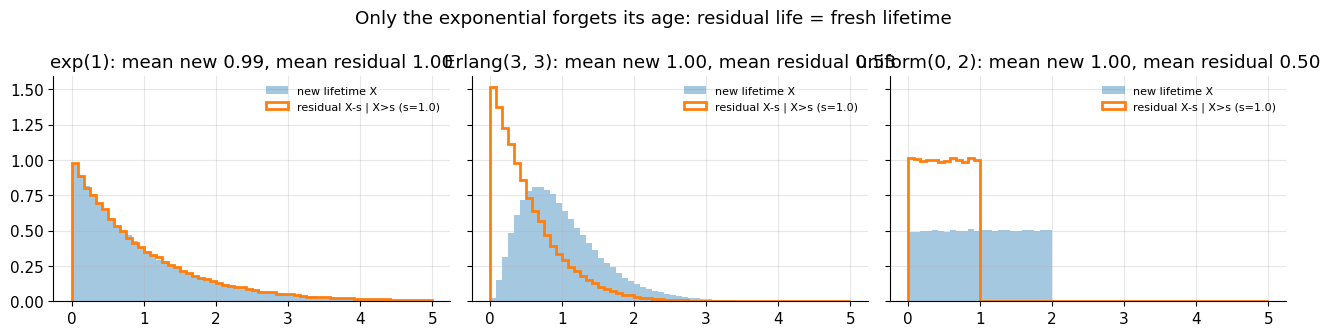

In [3]:
lam, s = 1.0, 1.0                                   # rate 1 per hour, age 1 hour
n = 200_000
X_exp = rng.exponential(1/lam, n)                   # exp(lambda)
X_erl = rng.gamma(3, 1/(3*lam), n)                  # Erlang(3, 3 lambda): same mean 1/lambda
X_uni = rng.uniform(0, 2/lam, n)                    # uniform on [0, 2/lambda]: same mean

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for a, (name, X) in zip(ax, [("exp(1)", X_exp), ("Erlang(3, 3)", X_erl), ("uniform(0, 2)", X_uni)]):
    res = X[X > s] - s                              # residual life given survival to age s
    a.hist(X, bins=60, range=(0, 5), density=True, alpha=.4, label="new lifetime X")
    a.hist(res, bins=60, range=(0, 5), density=True, histtype="step", lw=2, label=f"residual X-s | X>s (s={s})")
    a.set_title(f"{name}: mean new {X.mean():.2f}, mean residual {res.mean():.2f}"); a.legend(fontsize=8)
plt.suptitle("Only the exponential forgets its age: residual life = fresh lifetime"); plt.tight_layout(); plt.show()

**Think about it** — For the Erlang lifetime the residual mean is *smaller* than
the new mean (wear-out); for which kind of lifetime would it be *larger*? (Hint:
mixtures — e.g. half the components are lemons.)

---
## Problem 1 — E-mails: memorylessness at work *(slide p. 4/63)*

> I receive emails such that the time between two new emails is exponentially
> distributed with mean 2 minutes. I received an email at 10 am.
> (a) What is the probability that I receive the next email before 10:04am?
> (b) If I did not receive any email till 10:05am, what is the probability that I
> will receive no email till 10:07am? (c) If I did not receive any email till
> 10:10am, when can I expect the next email?

### Model
$X\sim\exp(\lambda)$ with $E[X]=1/\lambda=2$ min $\Rightarrow$ $\lambda=0.5$ per minute.
(a) $P(X<4)=1-e^{-2}$. (b) memoryless: $P(X>7\mid X>5)=P(X>2)=e^{-1}$.
(c) the remaining wait is again $\exp(0.5)$ with mean 2 min $\Rightarrow$ 10:12.

In [4]:
lam = 1 / 2.0                                # rate per minute
p_a = 1 - math.exp(-lam * 4)                 # (a) P(X < 4)
p_b = math.exp(-lam * 2)                     # (b) P(X > 7 | X > 5) = P(X > 2)
t_c = 10 + 2                                 # (c) expected time of the next e-mail, minutes after 10:00
print(f"(a) {p_a:.4f}   (b) {p_b:.4f}   (c) 10:{t_c:02d} AM")
print("scipy check:", stats.expon(scale=1/lam).cdf(4).round(4), stats.expon(scale=1/lam).sf(2).round(4))

(a) 0.8647   (b) 0.3679   (c) 10:12 AM
scipy check: 0.8647 0.3679


In [5]:
check("(a) P(X<4)",        p_a, 1 - math.exp(-2), tol=1e-6)
check("(b) P(X>7 | X>5)",   p_b, math.exp(-1),     tol=1e-6)
check("(c) minutes past 10", t_c, 12,               tol=1e-9)

[OK ] (a) P(X<4): got 0.864665   (reference 0.864665)
[OK ] (b) P(X>7 | X>5): got 0.367879   (reference 0.367879)
[OK ] (c) minutes past 10: got 12   (reference 12)


True

(a) sim: 0.8647    analytic: 0.8647
(b) sim: 0.367    analytic: 0.3679    (based on 82101 such mornings)
(c) sim: mean arrival time given none until 10:10 = 11.96 min past 10


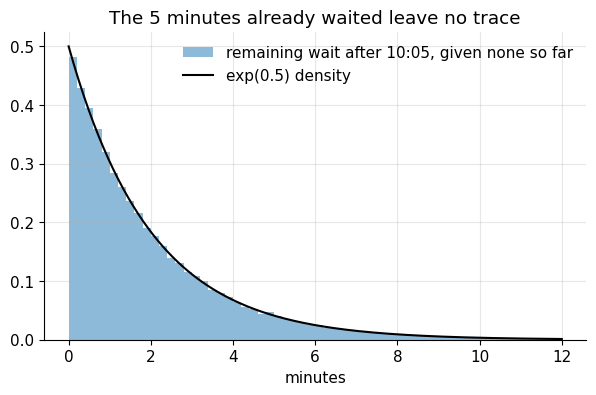

In [6]:
# --- Simulate: one million mornings; estimate (a) and (b) by counting ----------------------
X = rng.exponential(1/lam, 1_000_000)          # time (minutes after 10:00) of the next e-mail
E = stats.expon(scale=1/lam)                    # reference values from scipy (independent of your TODO)
print("(a) sim:", (X < 4).mean().round(4), "   analytic:", E.cdf(4).round(4))
alive = X > 5                                   # mornings with no e-mail until 10:05
print("(b) sim:", (X[alive] > 7).mean().round(4), "   analytic:", E.sf(2).round(4), f"   (based on {alive.sum()} such mornings)")
print("(c) sim: mean arrival time given none until 10:10 =", (10 + (X[X > 10] - 10).mean()).round(2), "min past 10")

plt.figure()
plt.hist(X[X > 5] - 5, bins=60, range=(0, 12), density=True, alpha=.5, label="remaining wait after 10:05, given none so far")
tt = np.linspace(0, 12, 200); plt.plot(tt, lam*np.exp(-lam*tt), "k", label="exp(0.5) density")
plt.xlabel("minutes"); plt.legend(); plt.title("The 5 minutes already waited leave no trace"); plt.show()

**Think about it** — (i) Rewrite (b) without memorylessness: $P(X>7)/P(X>5)$. Same
number — why? (ii) If inter-arrival times were *uniform* on $[0,4]$ minutes, what
would (b) be? (Now the past matters.)

---
## Problem 2 — Four welding stations: minimum of exponentials *(slides pp. 6–8/63)*

> The time to weld a part is exponential with parameter 3 (per hour). There are 4
> welding stations that begin to weld a part at 10am. (a) probability that the first
> weld is completed in 10 minutes; (b) expected time until the first weld;
> (c) expected time until the second weld; (d) at 10:20am none has finished —
> probability that the first job is completed before 10:25am, and the standard
> deviation of $Y$ = time after 10:20 until the first completion.

### Model
$X_1,\dots,X_4\sim\exp(3)$ per hour, independent. The first completion is
$Z=\min_i X_i\sim\exp(12)$: (a) $P(Z<\tfrac16)=1-e^{-2}$, (b) $E[Z]=\tfrac1{12}$ h $=5$ min.
(c) depends on the story: stations that **restart** immediately keep 4 clocks running
($E=\tfrac1{12}+\tfrac1{12}$ h); stations that **stop** after their part leave 3 clocks
($E=\tfrac1{12}+\tfrac19$ h). (d) memoryless: $Y\sim\exp(12)$ again, so
$P(Y<\tfrac1{12})=1-e^{-1}$ and $\mathrm{Std}(Y)=\tfrac1{12}$ h $=5$ min.

In [7]:
mu, k = 3.0, 4                                  # rate per station (per hour), number of stations
p_a = 1 - math.exp(-k*mu * (10/60))             # (a) min of 4 clocks ~ exp(12), 10 min = 1/6 h
mean_first = 60 / (k*mu)                        # (b) minutes
mean_second_restart = 60 * (1/(k*mu) + 1/(k*mu))        # (c) all 4 clocks keep running
mean_second_stop    = 60 * (1/(k*mu) + 1/((k-1)*mu))    # (c) 3 clocks remain
p_d   = 1 - math.exp(-k*mu * (5/60))            # (d) P(Y < 5 min), Y ~ exp(12)
std_Y = 60 / (k*mu)                             # (d) minutes: std of exp(12)
print(f"(a) {p_a:.4f}  (b) {mean_first:.2f} min  (c) restart {mean_second_restart:.2f} min / stop {mean_second_stop:.2f} min  (d) {p_d:.4f}, std {std_Y:.2f} min")

(a) 0.8647  (b) 5.00 min  (c) restart 10.00 min / stop 11.67 min  (d) 0.6321, std 5.00 min


In [8]:
check("(a) P(first < 10 min)",       p_a, 1 - math.exp(-2), tol=1e-6)
check("(b) E[first] (min)",           mean_first, 5.0, tol=1e-6)
check("(c) E[second], restart (min)", mean_second_restart, 10.0, tol=1e-6)
check("(c) E[second], stop (min)",    mean_second_stop, 60*(1/12 + 1/9), tol=1e-6)
check("(d) P(Y < 5 min)",             p_d, 1 - math.exp(-1), tol=1e-6)
check("(d) Std(Y) (min)",             std_Y, 5.0, tol=1e-6)

[OK ] (a) P(first < 10 min): got 0.864665   (reference 0.864665)
[OK ] (b) E[first] (min): got 5   (reference 5)
[OK ] (c) E[second], restart (min): got 10   (reference 10)
[OK ] (c) E[second], stop (min): got 11.6667   (reference 11.6667)
[OK ] (d) P(Y < 5 min): got 0.632121   (reference 0.632121)
[OK ] (d) Std(Y) (min): got 5   (reference 5)


True

(a) sim 0.8649   (b) sim 5.00 min   (c) sim restart 10.00 / stop 11.68 min
(d) sim P(Y<5) = 0.6173, std(Y) = 4.96 min   (runs kept: 3645)


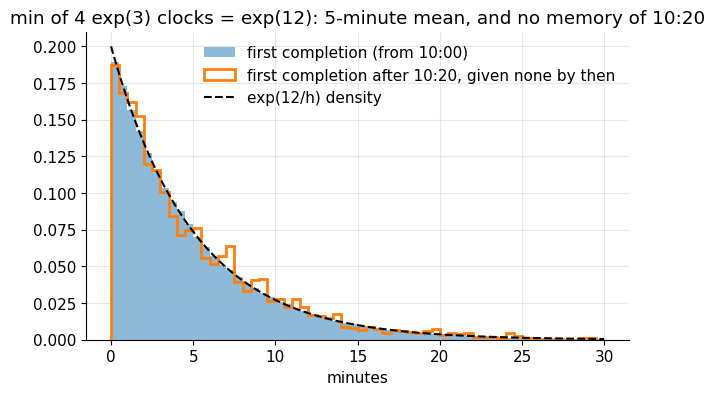

In [9]:
# --- Simulate the two versions of (c), plus (d) by conditioning on 'nobody done at 10:20' -----
n = 200_000
X = rng.exponential(1/mu, (n, k)) * 60                      # welding times in minutes, 4 stations
first  = X.min(axis=1)
second_stop = np.sort(X, axis=1)[:, 1]                       # stations stop: 2nd smallest of the 4 original times
X2 = rng.exponential(1/mu, (n, k)) * 60                      # stations restart: the finisher starts a new part
second_restart = np.minimum(np.sort(X, axis=1)[:, 1], first + X2[:, 0])
print(f"(a) sim {np.mean(first < 10):.4f}   (b) sim {first.mean():.2f} min   (c) sim restart {second_restart.mean():.2f} / stop {second_stop.mean():.2f} min")

# (d): at 10:20 all four are still busy -> keep only those runs and measure the time after 10:20
busy = first > 20
Y = first[busy] - 20
print(f"(d) sim P(Y<5) = {np.mean(Y < 5):.4f}, std(Y) = {Y.std():.2f} min   (runs kept: {busy.sum()})")

plt.figure()
plt.hist(first, bins=60, range=(0, 30), density=True, alpha=.5, label="first completion (from 10:00)")
plt.hist(Y, bins=60, range=(0, 30), density=True, histtype="step", lw=2, label="first completion after 10:20, given none by then")
tt = np.linspace(0, 30, 200); plt.plot(tt, (k*mu/60)*np.exp(-(k*mu/60)*tt), "k--", label="exp(12/h) density")
plt.xlabel("minutes"); plt.legend(); plt.title("min of 4 exp(3) clocks = exp(12): 5-minute mean, and no memory of 10:20"); plt.show()

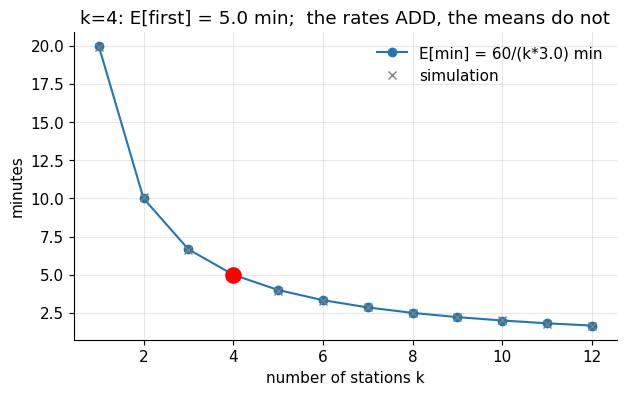

In [10]:
def stations_exp(k=4, mu=3.0):
    """E[first completion] = 1/(k mu) hours: more stations or faster stations shorten the wait."""
    ks = np.arange(1, 13)
    plt.figure(); plt.plot(ks, 60/(ks*mu), "o-", label=f"E[min] = 60/(k*{mu}) min"); plt.scatter([k], [60/(k*mu)], s=120, c="r", zorder=3)
    sim = [rng.exponential(1/mu, (20_000, kk)).min(axis=1).mean()*60 for kk in ks]
    plt.plot(ks, sim, "x", c="gray", label="simulation"); plt.xlabel("number of stations k"); plt.ylabel("minutes"); plt.legend()
    plt.title(f"k={k}: E[first] = {60/(k*mu):.1f} min;  the rates ADD, the means do not"); plt.show()

show(stations_exp, k=IntSlider(min=1, max=12, value=4) if HAS_W else 4,
     mu=FloatSlider(min=.5, max=10, step=.5, value=3) if HAS_W else 3.0)

**Think about it** — (i) In version "stop", the second completion has mean
$\tfrac1{12}+\tfrac19$ h; write the general formula for the $j$-th completion with
$k$ stations. (ii) Would (d) still be "5 minutes" if welding times were
deterministic 20 minutes? What would the answer be then?

---
## Problem 3 — East Gate traffic: Poisson counts, thinning, merging *(slides pp. 13–15/63)*

> Cars arrive at East Gate intersection according to a Poisson process with average
> arrival rate of 10 cars per minute. (a) no car in 10 seconds; (b) more than 2 cars in
> 15 seconds; (c) exactly 5 cars in 2 minutes; (d) expected number and (e) variance
> of cars in 10 minutes; (f) 40 % turn onto Jigok-dong, 50 % turn right at Hoja
> market — average inter-arrival time on each lane; (g) trucks $PP(8)$ and buses
> $PP(2)$ merge — probability of exactly 2 vehicles in 6 seconds.

### Model
$N(t)\sim$ Poisson$(\lambda t)$ with $\lambda=10$ per minute — **convert the time to
minutes first**. (f) thinning: lanes are $PP(4)$, $PP(1)$, $PP(5)$ with mean gaps
$\tfrac14$, $1$, $\tfrac15$ min. (g) merging: $PP(10)$, so $P(N(\tfrac1{10})=2)=e^{-1}/2$.

In [11]:
lam = 10.0                                          # cars per minute
p_a = stats.poisson(lam * 10/60).pmf(0)             # (a) 10 s
p_b = stats.poisson(lam * 15/60).sf(2)              # (b) more than 2 in 15 s
p_c = stats.poisson(lam * 2).pmf(5)                 # (c) exactly 5 in 2 min
mean_10 = lam * 10                                  # (d)
var_10  = lam * 10                                  # (e)
gaps_f  = [1/(lam*0.4), 1/(lam*0.1), 1/(lam*0.5)]   # (f) left, center, right lane: mean gap (minutes)
p_g = stats.poisson((8 + 2) * 6/60).pmf(2)          # (g) merged PP(10), 6 s
print(f"(a) {p_a:.4f} (b) {p_b:.4f} (c) {p_c:.2e} (d) {mean_10} (e) {var_10} (f) {np.round(gaps_f, 3)} min (g) {p_g:.4f}")

(a) 0.1889 (b) 0.4562 (c) 5.50e-05 (d) 100.0 (e) 100.0 (f) [0.25 1.   0.2 ] min (g) 0.1839


In [12]:
check("(a) P(N(10s)=0)",     p_a, math.exp(-10/6), tol=1e-6)
check("(b) P(N(15s)>2)",     p_b, 1 - math.exp(-2.5)*(1 + 2.5 + 2.5**2/2), tol=1e-6)
check("(c) P(N(2min)=5)",    p_c, math.exp(-20)*20**5/math.factorial(5), tol=1e-8)
check("(d) E[N(10)]",        mean_10, 100, tol=1e-9)
check("(e) Var[N(10)]",      var_10, 100, tol=1e-9)
check("(f) left-lane gap",   None if gaps_f[0] is Ellipsis else gaps_f[0], 0.25, tol=1e-9)
check("(f) center-lane gap", None if gaps_f[1] is Ellipsis else gaps_f[1], 1.0, tol=1e-9)
check("(f) right-lane gap",  None if gaps_f[2] is Ellipsis else gaps_f[2], 0.2, tol=1e-9)
check("(g) P(2 vehicles in 6s)", p_g, math.exp(-1)/2, tol=1e-6)

[OK ] (a) P(N(10s)=0): got 0.188876   (reference 0.188876)
[OK ] (b) P(N(15s)>2): got 0.456187   (reference 0.456187)
[OK ] (c) P(N(2min)=5): got 5.49641e-05   (reference 5.49641e-05)
[OK ] (d) E[N(10)]: got 100   (reference 100)
[OK ] (e) Var[N(10)]: got 100   (reference 100)
[OK ] (f) left-lane gap: got 0.25   (reference 0.25)
[OK ] (f) center-lane gap: got 1   (reference 1)
[OK ] (f) right-lane gap: got 0.2   (reference 0.2)
[OK ] (g) P(2 vehicles in 6s): got 0.18394   (reference 0.18394)


True

In [13]:
# --- Simulate: one long Poisson stream of cars; count, thin, merge --------------------------
T = 20_000                                            # minutes of traffic
cars = poisson_process(lam, T, rng)                   # arrival times (minutes)
print(f"{len(cars)} cars in {T} minutes: rate {len(cars)/T:.3f} per minute")

# (a)-(c): counts in windows of 10 s, 15 s, 2 min
def counts(times, w):                                 # number of events in consecutive windows of length w
    return np.bincount((times // w).astype(int), minlength=int(T // w))[:int(T // w)]
ref_a, ref_b, ref_c = stats.poisson(lam/6).pmf(0), stats.poisson(lam/4).sf(2), stats.poisson(2*lam).pmf(5)   # independent of your TODO
print("(a) sim:", (counts(cars, 1/6) == 0).mean().round(4), "  analytic:", ref_a.round(4))
print("(b) sim:", (counts(cars, 1/4) > 2).mean().round(4), "  analytic:", ref_b.round(4))
print("(c) sim:", (counts(cars, 2) == 5).mean(), "  analytic:", f"{ref_c:.2e}   (rare: ~{ref_c*T/2:.1f} windows expected)")
c10 = counts(cars, 10)
print(f"(d)(e) sim: mean {c10.mean():.1f}, var {c10.var():.1f}   analytic: 100, 100")

# (f) thinning: each car chooses a lane independently
u = rng.random(len(cars))
left, center, right = cars[u < 0.4], cars[(u >= 0.4) & (u < 0.5)], cars[u >= 0.5]
print("(f) sim mean gaps (min): left", np.diff(left).mean().round(3), "center", np.diff(center).mean().round(3), "right", np.diff(right).mean().round(3))

# (g) merging trucks and buses
vehicles = merge(poisson_process(8, T, rng), poisson_process(2, T, rng))
print("(g) sim:", (counts(vehicles, 0.1) == 2).mean().round(4), "  analytic:", stats.poisson(1.0).pmf(2).round(4))

200257 cars in 20000 minutes: rate 10.013 per minute
(a) sim: 0.1884   analytic: 0.1889
(b) sim: 0.4565   analytic: 0.4562
(c) sim: 0.0001   analytic: 5.50e-05   (rare: ~0.5 windows expected)
(d)(e) sim: mean 100.1, var 103.7   analytic: 100, 100
(f) sim mean gaps (min): left 0.25 center 1.0 right 0.2
(g) sim: 0.1839   analytic: 0.1839


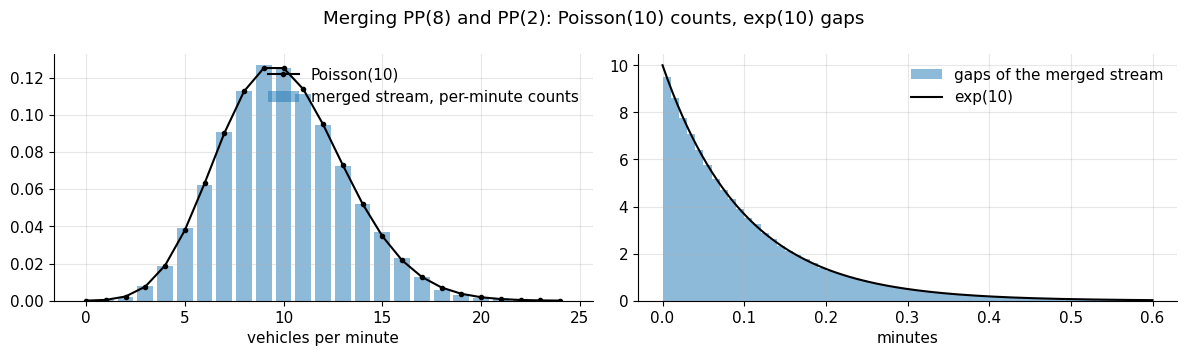

In [14]:
# --- Visualize: the merged stream is Poisson(10): count distribution and gap distribution ----
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
c = counts(vehicles, 1.0)
ks = np.arange(0, 25); ax[0].bar(ks, np.bincount(c, minlength=25)[:25]/len(c), alpha=.5, label="merged stream, per-minute counts")
ax[0].plot(ks, stats.poisson(10).pmf(ks), "ko-", ms=3, label="Poisson(10)"); ax[0].legend(); ax[0].set_xlabel("vehicles per minute")
g = np.diff(vehicles); ax[1].hist(g, bins=60, range=(0, .6), density=True, alpha=.5, label="gaps of the merged stream")
tt = np.linspace(0, .6, 200); ax[1].plot(tt, 10*np.exp(-10*tt), "k", label="exp(10)"); ax[1].legend(); ax[1].set_xlabel("minutes")
plt.suptitle("Merging PP(8) and PP(2): Poisson(10) counts, exp(10) gaps"); plt.tight_layout(); plt.show()

### Experiment — probabilistic thinning vs round-robin routing *(slide p. 12/63)*

A traffic light that sends **every other car** to the left lane also creates a
stream with 5 cars per minute on average — but it is **not** a Poisson process: its
gaps are sums of two exponentials, Erlang$(2,10)$, more regular than $\exp(5)$.
Same mean, half the variance. Watch the histogram and the count variance.

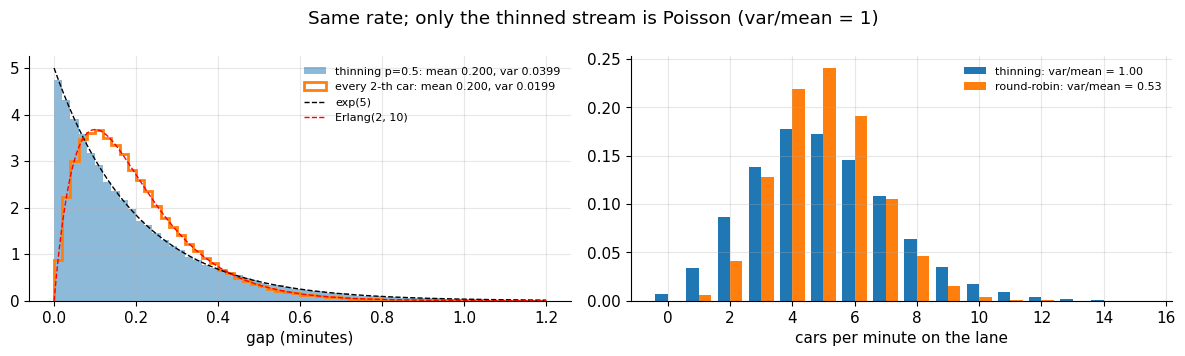

In [15]:
def thinning_vs_roundrobin(p=0.5):
    """Left lane by coin flip (thinning, prob p) versus by taking every k-th car (k = round(1/p))."""
    k = max(1, int(round(1/p)))
    lane_thin, _ = thin(cars, p, rng)                     # thin() returns (kept, dropped)
    lane_rr = cars[::k]
    g1, g2 = np.diff(lane_thin), np.diff(lane_rr)
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
    ax[0].hist(g1, bins=60, range=(0, 1.2), density=True, alpha=.5, label=f"thinning p={p}: mean {g1.mean():.3f}, var {g1.var():.4f}")
    ax[0].hist(g2, bins=60, range=(0, 1.2), density=True, histtype="step", lw=2, label=f"every {k}-th car: mean {g2.mean():.3f}, var {g2.var():.4f}")
    tt = np.linspace(0, 1.2, 200); ax[0].plot(tt, lam*p*np.exp(-lam*p*tt), "k--", lw=1, label=f"exp({lam*p:.0f})")
    ax[0].plot(tt, stats.gamma(k, scale=1/lam).pdf(tt), "r--", lw=1, label=f"Erlang({k}, {lam:.0f})"); ax[0].legend(fontsize=8); ax[0].set_xlabel("gap (minutes)")
    c1, c2 = counts(lane_thin, 1.0), counts(lane_rr, 1.0)
    ax[1].bar(np.arange(0, 16) - .2, np.bincount(c1, minlength=16)[:16]/len(c1), .4, label=f"thinning: var/mean = {c1.var()/c1.mean():.2f}")
    ax[1].bar(np.arange(0, 16) + .2, np.bincount(c2, minlength=16)[:16]/len(c2), .4, label=f"round-robin: var/mean = {c2.var()/c2.mean():.2f}")
    ax[1].set_xlabel("cars per minute on the lane"); ax[1].legend(fontsize=8)
    plt.suptitle("Same rate; only the thinned stream is Poisson (var/mean = 1)"); plt.tight_layout(); plt.show()

show(thinning_vs_roundrobin, p=FloatSlider(min=.2, max=.5, step=.05, value=.5) if HAS_W else .5)

**Think about it** — (i) Why does thinning keep the Poisson property? (Companion
Proof 3: condition on $N(t)$ and use the binomial.) (ii) Round-robin gives
$\text{var}/\text{mean}<1$ per minute. What would a *bursty* lane (cars in platoons)
give? (iii) The three lanes after thinning are **independent** Poisson processes —
the two lanes after round-robin are not. Design a check for that with the data above.

---
## Wrap-up

| question | tool | answer |
|---|---|---|
| e-mails (a)(b)(c) | memorylessness | $1-e^{-2}$, $e^{-1}$, 10:12 |
| welding (a)(b) | min of exponentials $\sim\exp(k\mu)$ | $1-e^{-2}$, 5 min |
| welding (c) | restart vs stop | 10 min vs $\tfrac7{36}$ h $\approx11.7$ min |
| welding (d) | memorylessness again | $1-e^{-1}$, Std 5 min |
| East Gate (a)–(e) | $N(t)\sim$ Poisson$(\lambda t)$ | $e^{-5/3}$, 0.456, $5.5\cdot10^{-5}$, 100, 100 |
| East Gate (f) | thinning | gaps $\tfrac14$, 1, $\tfrac15$ min |
| East Gate (g) | merging | $e^{-1}/2$ |

**Next (CP7):** exponential clocks, one per transition, *are* a CTMC — we build the
generator $Q$ for five systems.